In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

In [2]:
pip install sklearn_extra

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn_extra (from versions: none)

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sklearn_extra


In [4]:
df = pd.read_csv(r"C:/Users/Saee Beri/OneDrive/Desktop/Msc Datascience/Sem 2/ML Assignments/USArrests.csv") 

In [6]:
df.head(10)

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California
5,7.9,204,78,38.7,Colorado
6,3.3,110,77,11.1,Connecticut
7,5.9,238,72,15.8,Delaware
8,15.4,335,80,31.9,Florida
9,17.4,211,60,25.8,Georgia


In [7]:
X = StandardScaler().fit_transform(df.select_dtypes("number"))
X

array([[ 1.25517927,  0.79078716, -0.52619514, -0.00345116],
       [ 0.51301858,  1.11805959, -1.22406668,  2.50942392],
       [ 0.07236067,  1.49381682,  1.00912225,  1.05346626],
       [ 0.23470832,  0.23321191, -1.08449238, -0.18679398],
       [ 0.28109336,  1.2756352 ,  1.77678094,  2.08881393],
       [ 0.02597562,  0.40290872,  0.86954794,  1.88390137],
       [-1.04088037, -0.73648418,  0.79976079, -1.09272319],
       [-0.43787481,  0.81502956,  0.45082502, -0.58583422],
       [ 1.76541475,  1.99078607,  1.00912225,  1.1505301 ],
       [ 2.22926518,  0.48775713, -0.38662083,  0.49265293],
       [-0.57702994, -1.51224105,  1.21848371, -0.11129987],
       [-1.20322802, -0.61527217, -0.80534376, -0.75839217],
       [ 0.60578867,  0.94836277,  1.21848371,  0.29852525],
       [-0.13637203, -0.70012057, -0.03768506, -0.0250209 ],
       [-1.29599811, -1.39102904, -0.5959823 , -1.07115345],
       [-0.41468229, -0.67587817,  0.03210209, -0.34856705],
       [ 0.44344101, -0.

In [8]:
def elbow_sse(X, max_k=10):
    """Return list of SSE (inertia) for k=2..max_k using K‑means."""
    return [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_
            for k in range(2, max_k + 1)]

In [9]:
def silhouette_curve(model_cls, X, max_k=10):
    """Return list of avg. silhouette scores for k=2..max_k."""
    scores = []
    for k in range(2, max_k + 1):
        labels = model_cls(n_clusters=k, random_state=42).fit_predict(X)
        scores.append(silhouette_score(X, labels))
    return scores

In [ ]:
sse          = elbow_sse(X)
sil_kmeans   = silhouette_curve(KMeans,   X)
sil_kmedoids = silhouette_curve(KMedoids, X)

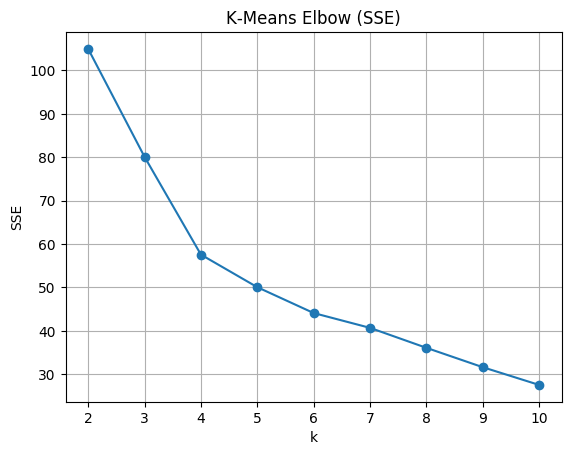

In [12]:
plt.figure()
plt.plot(range(2, 11), sse, marker="o")
plt.title("K‑Means Elbow (SSE)"); plt.xlabel("k"); plt.ylabel("SSE"); plt.grid(True)

NameError: name 'sil_kmedoids' is not defined

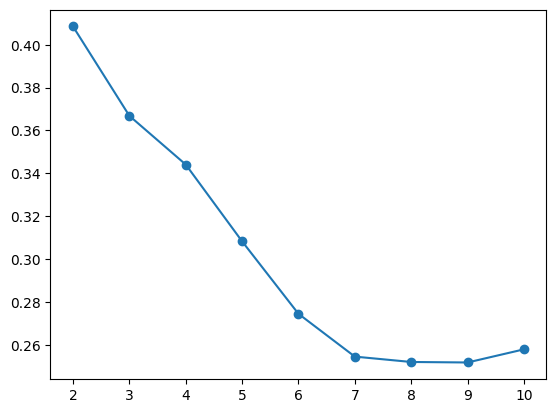

In [13]:
plt.figure()
plt.plot(range(2, 11), sil_kmeans,  marker="o", label="K‑Means")
plt.plot(range(2, 11), sil_kmedoids, marker="x", linestyle="--", label="K‑Medoids")
plt.title("Average Silhouette Score"); plt.xlabel("k"); plt.ylabel("Silhouette")
plt.legend(); plt.grid(True)
plt.show()

In [ ]:
best_k_kmeans   = sil_kmeans .index(max(sil_kmeans )) + 2
best_k_kmedoids = sil_kmedoids.index(max(sil_kmedoids)) + 2
print(f"\nOptimal k  →  K‑Means: {best_k_kmeans},  K‑Medoids: {best_k_kmedoids}")

In [ ]:
kmeans_final   = KMeans  (n_clusters=best_k_kmeans,   n_init=10, random_state=42).fit(X)
kmedoids_final = KMedoids(n_clusters=best_k_kmedoids, random_state=42).fit(X)

In [ ]:
kmedoids_final

In [ ]:
df["KMeans_cluster"]   = kmeans_final.labels_
df["KMedoids_cluster"] = kmedoids_final.labels_

In [18]:
print("\nClustered data (first 10 rows):")
print(df.head(10))


Clustered data (first 10 rows):
   Murder  Assault  UrbanPop  Rape        State  KMeans_cluster
0    13.2      236        58  21.2      Alabama               1
1    10.0      263        48  44.5       Alaska               1
2     8.1      294        80  31.0      Arizona               1
3     8.8      190        50  19.5     Arkansas               0
4     9.0      276        91  40.6   California               1
5     7.9      204        78  38.7     Colorado               1
6     3.3      110        77  11.1  Connecticut               0
7     5.9      238        72  15.8     Delaware               0
8    15.4      335        80  31.9      Florida               1
9    17.4      211        60  25.8      Georgia               1
